In [1]:
import pandas as pd
import numpy as np
import os
import h5py

In [2]:
fileid = 'stimSubject10'  # Example file ID

In [3]:
osd_output = f'/d/cdac Dropbox/Wolfgang Ganglberger/WolfgangGanglberger/CLAS_Teun_Project/OSD_predictions/{fileid}.csv'
df_osd = pd.read_csv(osd_output)
df_osd = df_osd[['OSD']]
print(df_osd.shape)
df_osd.head()

(9755, 1)


,OSD
0,1.001126
1,1.001126
2,1.001126
3,0.558907
4,0.747801


In [4]:
eeg = f'/d/cdac Dropbox/Wolfgang Ganglberger/WolfgangGanglberger/CLAS_Teun_Project/prepared_data/{fileid}.h5'
eeg = h5py.File(eeg, 'r')
# signals/c4-m1:
eeg_data = eeg['signals']['c4-m1'][:]
eeg_data = eeg_data.astype(np.float32).squeeze() * 1e6  # Convert from V to µV
print(eeg_data.shape)

(5853502,)


In [5]:
len(eeg_data) / len(df_osd)  # Check if lengths match
# OSD gives a value each 600 samples (i.e. 3 seconds at 200 Hz)
# scale df_osd accordingly, i.e. repeat each value 600 times
df_osd_expanded = np.repeat(df_osd['OSD'].values, 600)
print(df_osd_expanded.shape)
# if shape is off by less than 600, fill with 0s
if len(eeg_data) > len(df_osd_expanded):
    diff = len(eeg_data) - len(df_osd_expanded)
    assert diff < 600
    df_osd_expanded = np.concatenate([df_osd_expanded, np.zeros(diff)])
assert len(eeg_data) == len(df_osd_expanded)

(5853000,)


In [ ]:
# compute 0.5 - 4Hz bandpower of eeg_data in 600 sample windows but have the same length as eeg_data
from scipy.signal import welch
bandpower = []
for i in range(0, len(eeg_data), 600):
    f, Pxx = welch(eeg_data[i:i+600], fs=200, nperseg=600)
    bp = np.trapz(Pxx[(f >= 0.5) & (f <= 4)], f[(f >= 0.5) & (f <= 4)])
    bandpower.extend([bp]*600)
bandpower = np.array(bandpower)
print(bandpower.shape)
if len(bandpower) > len(eeg_data):
    assert len(bandpower) - len(eeg_data) < 600
    bandpower = bandpower[:len(eeg_data)]

/home/wolfgang/miniconda3/envs/oracle/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:589: UserWarning: nperseg = 600 is greater than input length  = 502, using nperseg = 502
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


(5853600,)


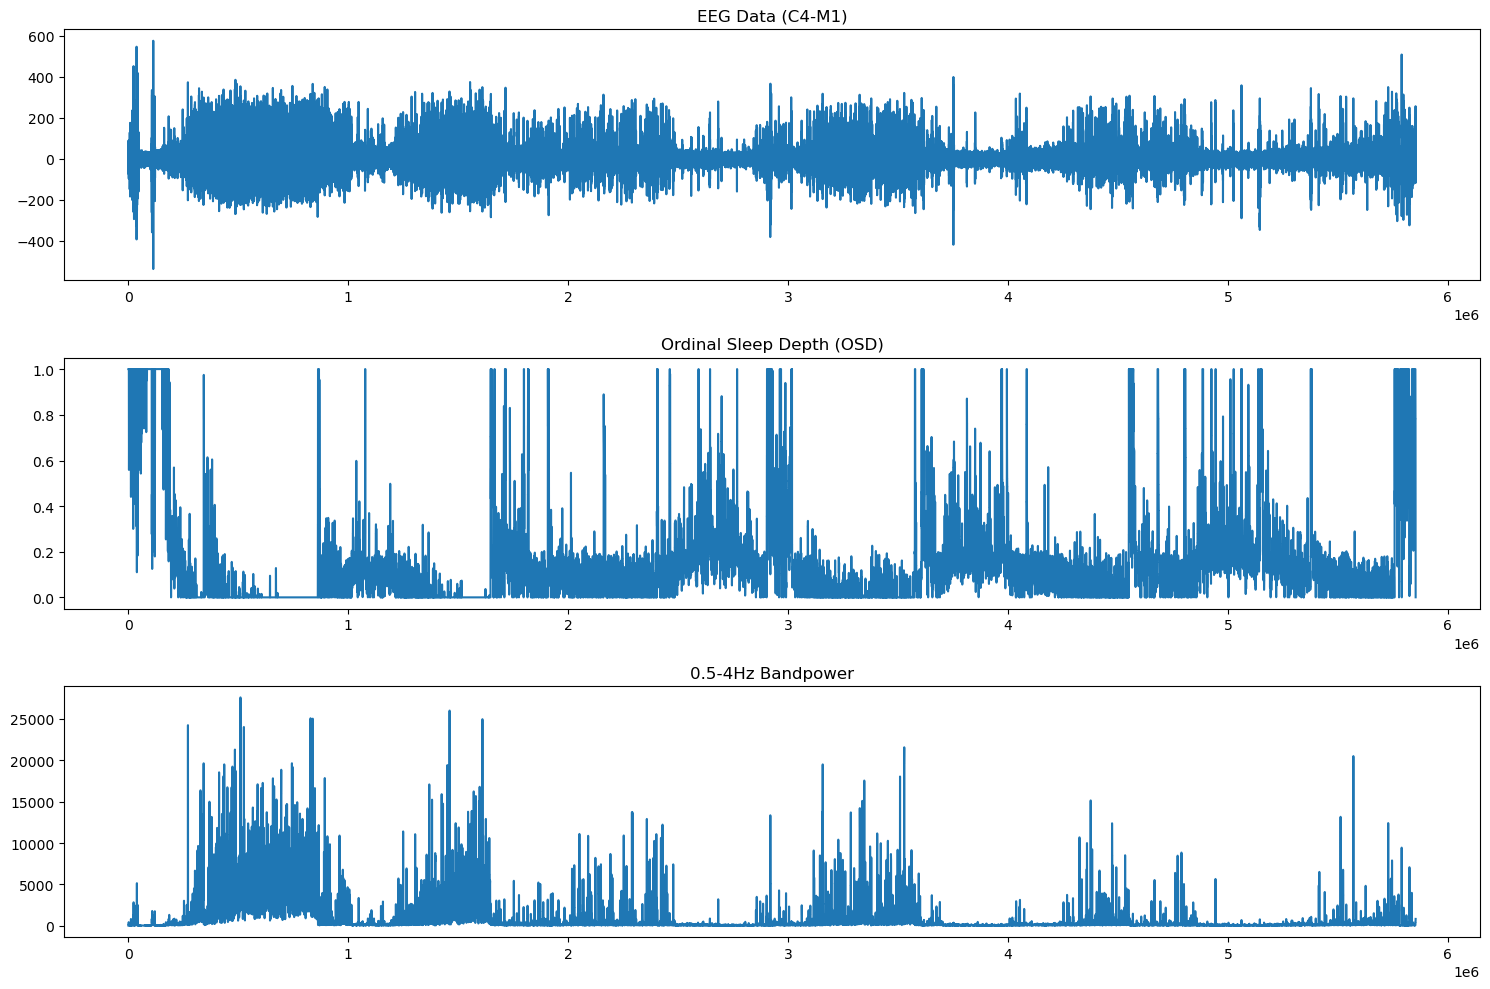

In [8]:
# 3x1 plot of eeg_data, df_osd_expanded, bandpower
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
plt.subplot(3,1,1)
plt.plot(eeg_data)
plt.title('EEG Data (C4-M1)')
plt.subplot(3,1,2)
plt.plot(df_osd_expanded)
plt.title('Ordinal Sleep Depth (OSD)')
plt.subplot(3,1,3)
plt.plot(bandpower)
plt.title('0.5-4Hz Bandpower')
plt.tight_layout()
plt.show()